In [ ]:
# necessary imports

import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector as cnt
import requests

print(f'{os.getcwd()}')
print(f'{pd.__version__=}\n{np.__version__=}')

c:\Users\kteti\Desktop\Liuxey\VilniusCoding\VilniusCoding
pd.__version__='3.0.5'
np.__version__='2.5.2'


In [ ]:
# establishing database connection

DB = cnt.connect(
    host = 'localhost',
    user='root',
    password='*YOUR_PASSWORD*',
    port=3306
    )
C=DB.cursor()

C.execute("use project;")

In [ ]:
# importing customers dataset using SQL script + Pandas

SQL = '''
with C as (select customer_id as id, customer_name from customers),
A as
(select *,
case
	when MONTH(load_date) >= 3 and MONTH(load_date) < 6 then 'Spring'
    when MONTH(load_date) >= 6 and MONTH(load_date) < 9 then 'Summer'
    when MONTH(load_date) >= 9 and MONTH(load_date) <12 then 'Autumn'
    else 'Winter'
end as Season
from loads),
B as (select customer_id, season, count(*) as kiekis, avg(revenue) as rev,
row_number() over(partition by customer_id order by season asc) as R
from A
group by customer_id, season
order by customer_id asc)
select id, customer_name, season, kiekis, rev, r from B
inner join C
on B.customer_id = C.id;
'''
seasonal = pd.read_sql_query(SQL, con=DB)
seasonal.head()

,id,customer_name,season,kiekis,rev,r
0,CUST00001,Metro Wholesale,Autumn,119,3233.935378,1
1,CUST00001,Metro Wholesale,Spring,93,3430.608387,2
2,CUST00001,Metro Wholesale,Summer,103,3038.358641,3
3,CUST00001,Metro Wholesale,Winter,120,3033.126750,4
4,CUST00002,National Retail,Autumn,91,3374.839780,1


In [ ]:
# importing drivers KPI dataset using SQL script + Pandas

SQL = '''
with DRI as
(select driver_id, concat(first_name, ' ', last_name) as Name,
2026-YEAR(date_of_birth) as Age,
employment_status as Status, years_experience as Exp
from drivers),
METRICS as
(select driver_id, 
sum(trips_completed) as TripsTotal, 
round(sum(total_miles * 1.60934), 0) as DistanceTotal, 
round(sum(total_revenue), 0) as RevenueTotal, 
round(avg((total_miles * 1.60934) / (total_fuel_gallons * 3.78541)), 3) as "Km/L", 
round(sum(total_fuel_gallons * 3.78541), 0) as FuelTotal, 
round(avg(on_time_delivery_rate), 3) as OnTimeRate,
round(avg(total_revenue/ (total_miles * 1.60934)), 3) as Rev_per_KM
from driver_monthly_metrics
group by driver_id)
select Name, Age, Status, Exp, TripsTotal, DistanceTotal, RevenueTotal, `Km/L`, FuelTotal, OnTimeRate, Rev_per_KM from DRI
inner join METRICS
on DRI.driver_id = METRICS.driver_id;
'''
metrics = pd.read_sql_query(SQL, con=DB)
metrics.head()

,Name,Age,Status,Exp,TripsTotal,DistanceTotal,RevenueTotal,Km/L,FuelTotal,OnTimeRate,Rev_per_KM
0,Jennifer Hernandez,53,Active,3,632.0,1497066.0,1985683.0,2.732,547771.0,0.454,3.430
1,William Martin,50,Active,20,662.0,1518004.0,2073621.0,2.746,554944.0,0.468,3.530
2,Charles Hernandez,56,Active,19,677.0,1625812.0,2146977.0,2.756,590137.0,0.451,3.418
3,Barbara Brown,31,Active,19,659.0,1581378.0,2119361.0,2.746,575924.0,0.428,3.479
4,Mary Martinez,66,Active,12,643.0,1485627.0,2022357.0,2.732,543103.0,0.454,3.520


In [ ]:
# importing loads/distance dataset using SQL script + Pandas

SQL = '''
with A as (select load_id, load_date, revenue,  concat(origin_city, ' -> ', destination_city) as route, 
typical_distance_miles * 1.61 as distanceKMS, round(revenue/ (typical_distance_miles*1.60934), 3) as revenue_per_km
from loads
inner join routes
on loads.route_id = routes.route_id)
select *,
case
	when distanceKMS < 150 then '<150'
    when distanceKMS >= 150 and distanceKMS < 300 then '150-300'
    when distanceKMS >= 300 and distanceKMS < 500 then '300-500'
    when distanceKMS >= 500 and distanceKMS < 800 then '500-800'
    when distanceKMS >= 800 and distanceKMS < 1200 then '800-1200'
    when distanceKMS >= 1200 and distanceKMS < 2000 then '1200-2000'
    when distanceKMS >= 2000 and distanceKMS < 3000 then '2000-3000'
    else '3000+'
end as distancegroup
from A;
'''
loads = pd.read_sql_query(SQL, con=DB)

order = ['<150', '150-300', '300-500', '500-800', '800-1200', '1200-2000', '2000-3000', '3000+']

In [ ]:
# rounding distance so I have more accurate tendency in my visualisation and distance is grouped easier

loads['distance'] = (loads['distanceKMS'] // 100) * 100
loads.head()


,load_id,load_date,revenue,route,distanceKMS,eur_per_km,distancegroup,distance
0,LOAD00000001,2022-01-01,3045.23,Houston -> Detroit,2046.31,3.857,2000-3000,2000.0
1,LOAD00000002,2022-01-01,1224.48,Kansas City -> Indianapolis,835.59,3.798,800-1200,800.0
2,LOAD00000003,2022-01-01,7171.12,Columbus -> Portland,3754.52,4.951,3000+,3700.0
3,LOAD00000004,2022-01-01,1308.20,Phoenix -> Denver,1083.53,3.130,800-1200,1000.0
4,LOAD00000005,2022-01-01,3317.18,Houston -> Seattle,3496.92,2.459,3000+,3400.0


In [ ]:
# creating a new table using MEAN aggregation to count average rate/km per load distance group

table = loads.groupby('distance').agg({'eur_per_km':'mean'}).reset_index()
table.head()

,distance,eur_per_km
0,100.0,3.558245
1,200.0,3.880806
2,400.0,4.229139
3,700.0,3.314105
4,800.0,3.154790


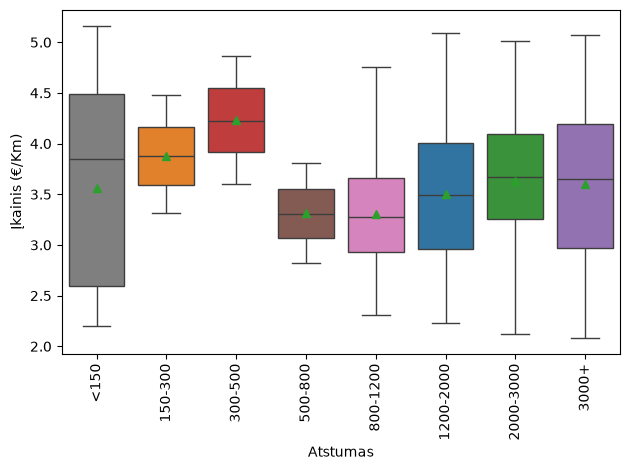

In [ ]:
# seaborn boxplot visualisation showing rate/km for avg + median for each load distance group

fig, axis = plt.subplots()
sns.boxplot(data=loads.sort_values(by='distancegroup'), x='distancegroup', y='eur_per_km', showmeans=True, showfliers=False, hue='distancegroup', order=order)
plt.xticks(rotation=90)
plt.ylabel('Revenue_per_Km')
plt.xlabel('Atstumas')
plt.tight_layout()
plt.show()

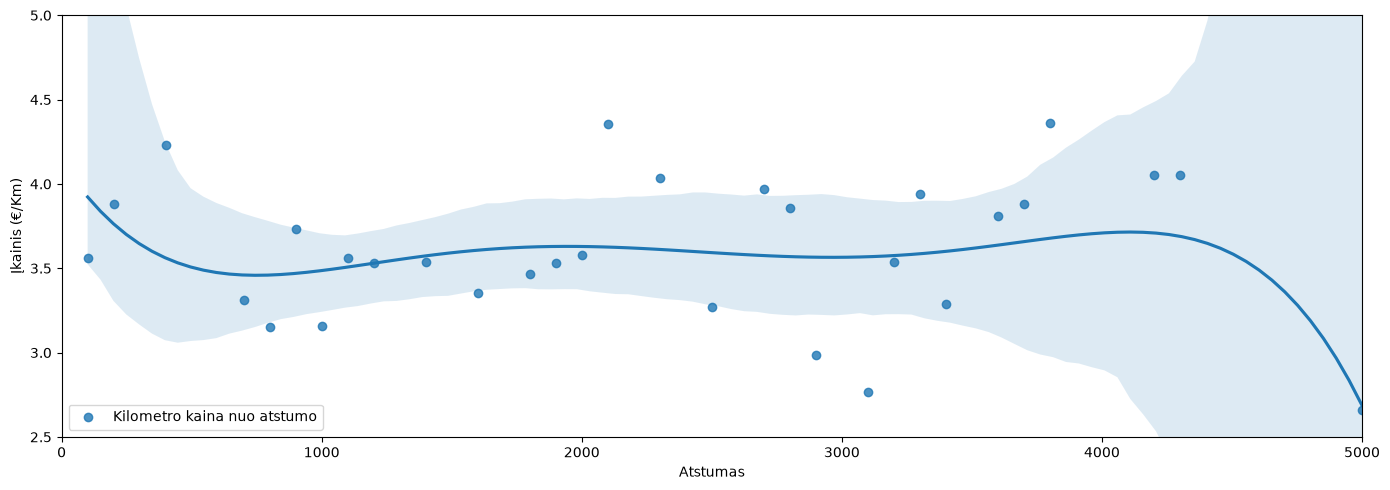

In [ ]:
# seaborn regplot visualisation showing tendency of rate/km by load distance

fig, axis = plt.subplots(figsize=[14,5])
gr = sns.regplot(data=table, x='distance', y='revenue_per_km', order=5, label='Kilometro kaina nuo atstumo')
plt.xlim(0, 5000)
plt.ylim(2.5, 5)
plt.legend(loc='best')
plt.ylabel('Revenue_per_Km')
plt.xlabel('Atstumas')
plt.tight_layout()
plt.show()


In [ ]:
# importing "on time/late" deliveries dataset using SQL script + Pandas / changing needed columns to date/time format

SQL = '''
select event_id, event_type, DATE_FORMAT(scheduled_datetime, '%Y-%m-%d %H:%i:%s') as scheduled_date, DATE_FORMAT(actual_datetime, '%Y-%m-%d %H:%i:%s') as actual_date,
on_time_flag, actual_distance_miles*1.60934 as distancekms from delivery_events
inner join trips
on delivery_events.trip_id = trips.trip_id
where event_type = 'Delivery';
'''
velavimai = pd.read_sql_query(SQL, con=DB)
velavimai['scheduled_date'] = pd.to_datetime(velavimai['scheduled_date'])
velavimai['actual_date'] = pd.to_datetime(velavimai['actual_date'])
velavimai.head()

,event_id,event_type,scheduled_date,actual_date,on_time_flag,distancekms
0,EVT00000002,Delivery,2022-01-02 23:10:55,2022-01-02 21:30:22,True,2115.54
1,EVT00000004,Delivery,2022-01-02 02:13:26,2022-01-02 05:55:46,False,829.15
2,EVT00000006,Delivery,2022-01-03 04:28:02,2022-01-03 03:05:02,True,4039.49
3,EVT00000008,Delivery,2022-01-02 06:38:56,2022-01-02 08:41:06,False,1154.37
4,EVT00000010,Delivery,2022-01-02 22:51:35,2022-01-02 22:23:50,True,3611.23


In [ ]:
# rounding distance again so we could use more grouped distance metrics in visualisations

velavimai['distancegr'] = (velavimai['distancekms'] // 100) * 100
velavimai.head()

,event_id,event_type,scheduled_date,actual_date,on_time_flag,distancekms,distancegr
0,EVT00000002,Delivery,2022-01-02 23:10:55,2022-01-02 21:30:22,True,2115.54,2100.0
1,EVT00000004,Delivery,2022-01-02 02:13:26,2022-01-02 05:55:46,False,829.15,800.0
2,EVT00000006,Delivery,2022-01-03 04:28:02,2022-01-03 03:05:02,True,4039.49,4000.0
3,EVT00000008,Delivery,2022-01-02 06:38:56,2022-01-02 08:41:06,False,1154.37,1100.0
4,EVT00000010,Delivery,2022-01-02 22:51:35,2022-01-02 22:23:50,True,3611.23,3600.0


In [ ]:
# creating a new dataset with total count of on time and late deliveries + same metrics in %

ontime = (velavimai.groupby(by=['distancegr', 'on_time_flag']).size().reset_index(name='count'))
ontime['total'] = ontime.groupby('distancegr')['count'].transform('sum')
ontime['proc'] = round(ontime['count'] / ontime['total'] * 100, 2)
ontime.head()


,distancegr,on_time_flag,count,total,proc
0,100.0,False,1675,3005,55.74
1,100.0,True,1330,3005,44.26
2,200.0,False,847,1491,56.81
3,200.0,True,644,1491,43.19
4,400.0,False,805,1522,52.89


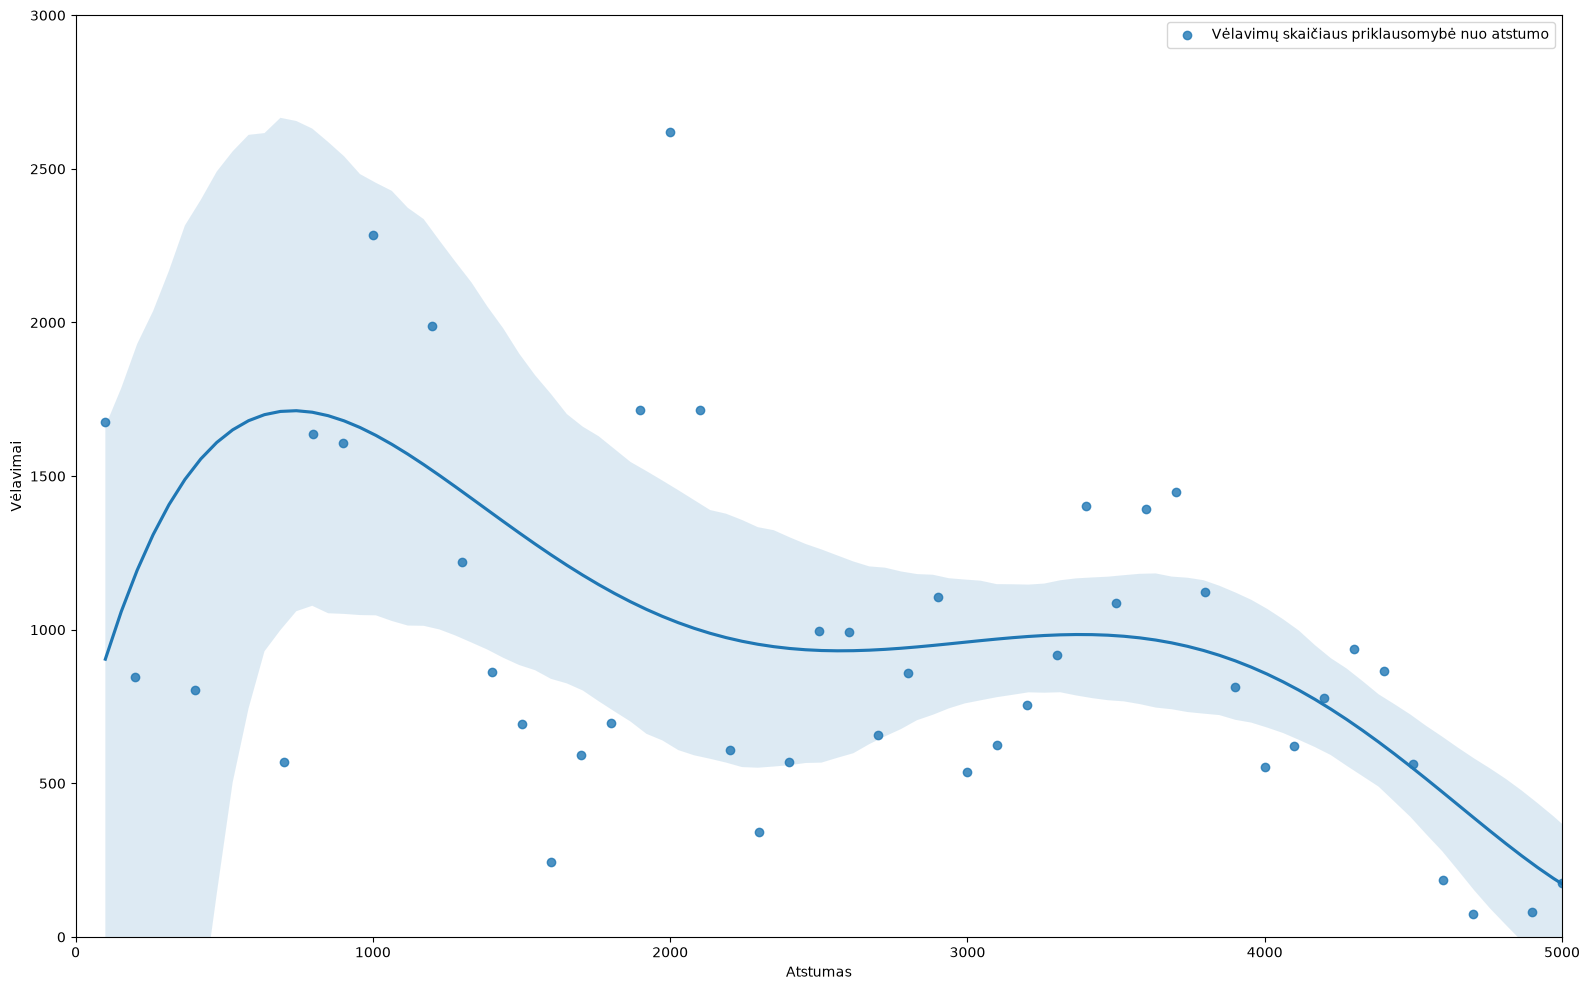

In [ ]:
# seaborn regplot visualisation showing tendency of late deliveries by distance covered

fig, axis = plt.subplots(figsize=[16,10])

sns.regplot(data=ontime[ontime['on_time_flag'] == 'False'], x='distancegr', y='count', order=5, label='Vėlavimų skaičiaus priklausomybė nuo atstumo')

plt.xlim(0, 5000)
plt.ylim(0, 3000)
plt.legend(loc='best')
plt.ylabel('Vėlavimai')
plt.xlabel('Atstumas')
plt.tight_layout()
plt.show()

In [ ]:
# new dataset import with incidents, dates and responsible drivers using SQL script + Pandas

SQL = '''
with driver as
(select driver_id, concat(first_name, ' ', last_name) as name, 2026-YEAR(date_of_birth) as age, years_experience from drivers),
incident as
(select incident_id, driver_id, incident_date, MONTH(incident_date) as mennr, MONTHNAME(incident_date) as month from safety_incidents)
select incident_id, incident_date, mennr, month, name, age, years_experience
from incident
inner join driver
on incident.driver_id = driver.driver_id;
'''
incident = pd.read_sql_query(SQL, con=DB)
incident.head()

,incident_id,incident_date,mennr,month,name,age,years_experience
0,INC00000001,2023-04-09 14:00:00,4,April,Robert Taylor,36,23
1,INC00000002,2023-02-19 11:00:00,2,February,Robert Taylor,36,23
2,INC00000003,2024-05-20 01:00:00,5,May,Jennifer Wilson,43,6
3,INC00000004,2023-09-26 03:00:00,9,September,Linda Moore,43,18
4,INC00000005,2024-03-20 14:00:00,3,March,Mary Wilson,50,9


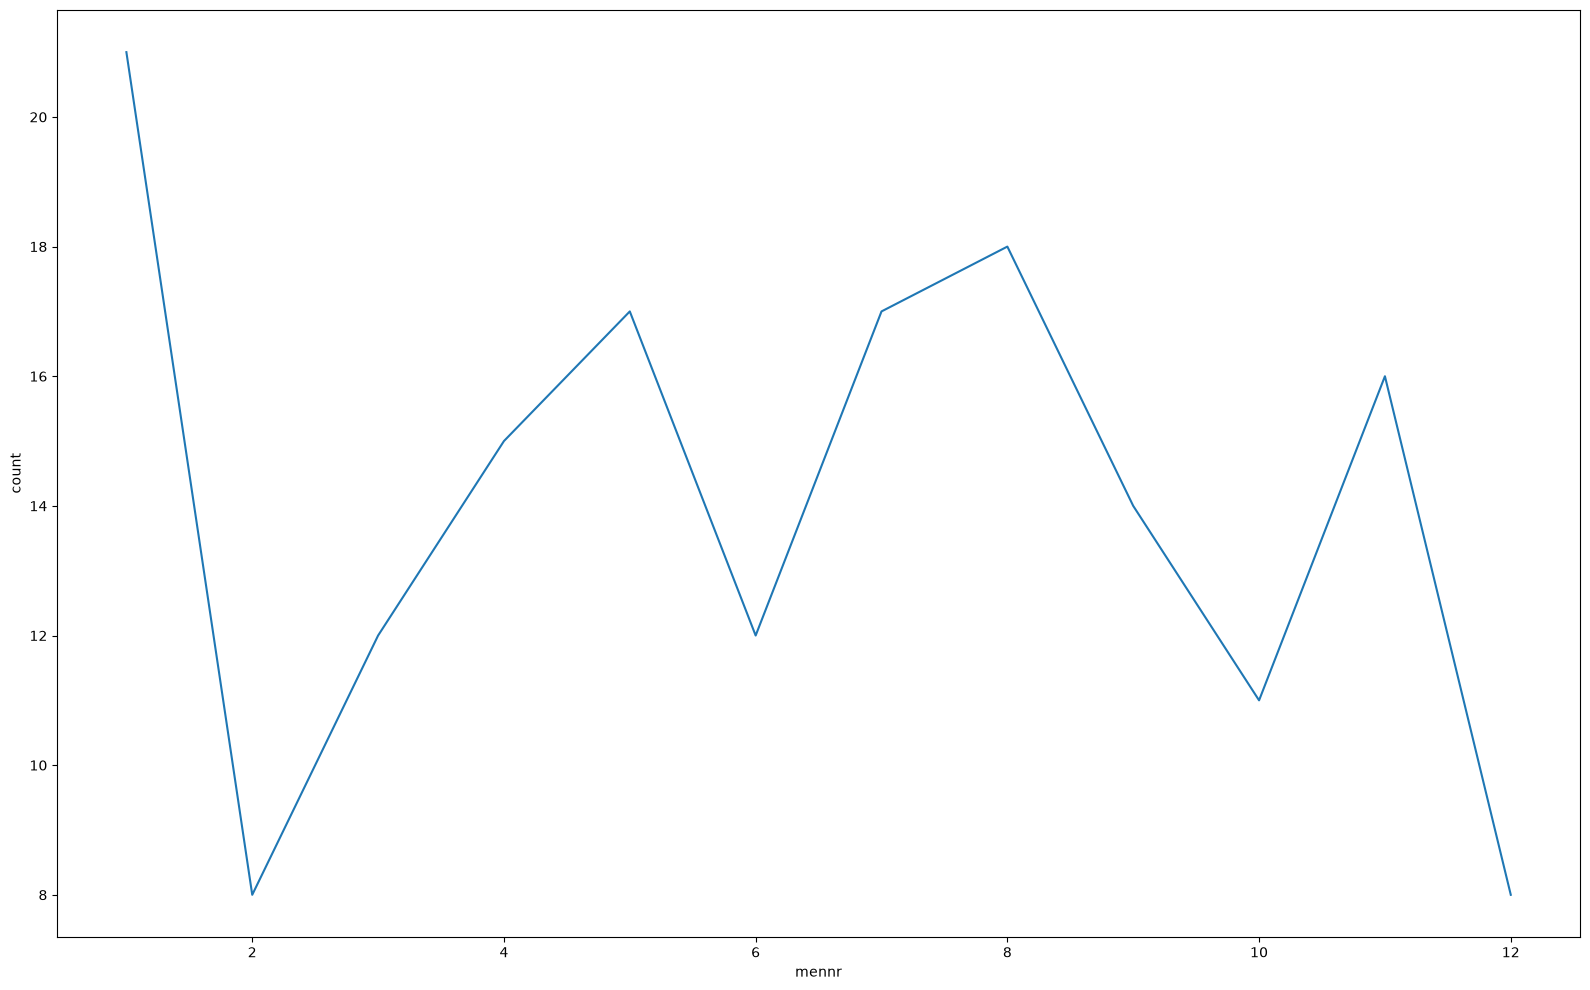

In [ ]:
# seaborn lineplot visualisation showing count of accidents by month to see any tendencies

incidentgroup = incident.groupby('mennr').size().reset_index(name='count')
fig, axis = plt.subplots(figsize=[16,10])

sns.lineplot(data=incidentgroup, x='mennr', y='count', ax=axis)

plt.tight_layout()
plt.show()

In [ ]:
# creating drivers age and experience groups using own functions

def age(x):
    if x < 35:
        return '<35'
    if x >= 35 and x < 40:
        return '35-39'
    if x >= 40 and x < 45:
        return '40-44'
    if x >= 45 and x < 50:
        return '45-49'
    if x >= 50 and x < 55:
        return '50-54'
    if x >= 55 and x < 60:
        return '55-59'
    else:
        return '60+'

incident['agegr'] = incident['age'].apply(age)

def exp(x):
    if x < 3:
        return '0-3'
    if x >= 3 and x < 6:
        return '3-5'
    if x >= 6 and x < 10:
        return '5-10'
    if x >= 10 and x < 16:
        return '10-15'
    if x >= 16 and x < 21:
        return '16-20'
    else:
        return '21+'

incident['expgr'] = incident['years_experience'].apply(exp)

incident.head()

,incident_id,incident_date,mennr,month,name,age,years_experience,agegr,expgr
0,INC00000001,2023-04-09 14:00:00,4,April,Robert Taylor,36,23,35-39,21+
1,INC00000002,2023-02-19 11:00:00,2,February,Robert Taylor,36,23,35-39,21+
2,INC00000003,2024-05-20 01:00:00,5,May,Jennifer Wilson,43,6,40-44,5-10
3,INC00000004,2023-09-26 03:00:00,9,September,Linda Moore,43,18,40-44,16-20
4,INC00000005,2024-03-20 14:00:00,3,March,Mary Wilson,50,9,50-54,5-10


In [ ]:
# incident locations dataset import using SQL + Pandas

SQL = '''
select incident_id, location_city from safety_incidents;
'''
incidentmap = pd.read_sql_query(SQL, con=DB)
incidentmap.head()

,incident_id,location_city
0,INC00000001,Columbus
1,INC00000002,Columbus
2,INC00000003,Seattle
3,INC00000004,Kansas City
4,INC00000005,Las Vegas


In [ ]:
# new dataset import of trucks and service occurance info using SQL script + Pandas

SQL = '''
with A as
(select maintenance_id, truck_id, odometer_reading, total_cost, downtime_hours from maintenance_records),
B as
(select truck_id, make, model_year from trucks)
select maintenance_id as id, odometer_reading as odometer, total_cost as cost, downtime_hours as hours, make as brand, model_year as year from A
inner join B
on A.truck_id = B.truck_id;
'''
service = pd.read_sql_query(SQL, con=DB)
service['odometer'] = ( service['odometer'] // 5000 ) * 5000
service['cost'] = ( service['cost'] // 100) * 100
service.head()

,id,odometer,cost,hours,brand,year
0,MAINT00000001,400000,700.0,22.2,Kenworth,2015
1,MAINT00000002,265000,3200.0,8.0,International,2015
2,MAINT00000003,695000,2300.0,16.5,Volvo,2017
3,MAINT00000004,415000,300.0,34.6,Kenworth,2015
4,MAINT00000005,175000,1300.0,4.4,International,2016


<Axes: xlabel='odometer', ylabel='id'>

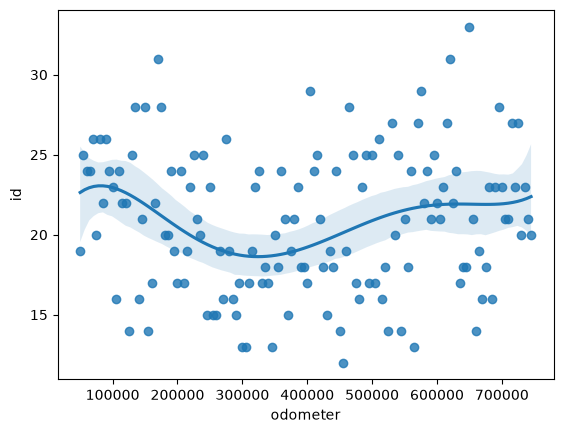

In [ ]:
# seaborn regplot visualisation to see if there are any tendencies of truck service occurance count by total odometer

odgr = service.groupby(by='odometer').agg({'id' : 'count'}).reset_index()
odgr.head()

sns.regplot(data=odgr, x='odometer', y='id', order=5)

<Axes: xlabel='year', ylabel='id'>

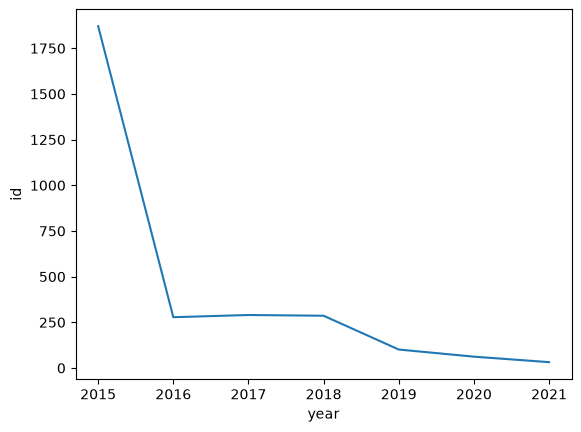

In [ ]:
# lineplot visualisation showing count of service occurance by year of trucks

yeargr = service.groupby('year').agg({'id' : 'count'}).reset_index()
sns.lineplot(data=yeargr, x='year', y='id')

<Axes: xlabel='brand', ylabel='id'>

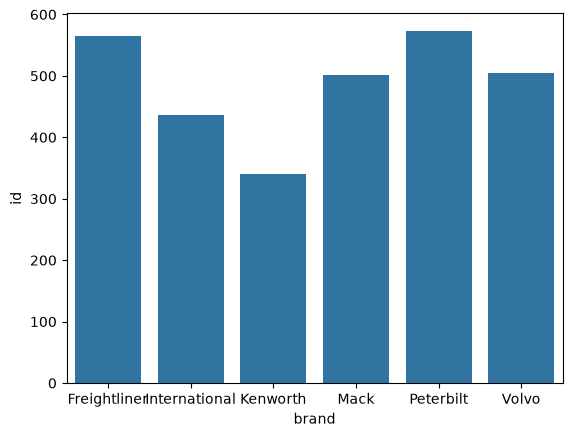

In [ ]:
# seaborn barplot visualisation showing count of service occurances by truck brand name

brand = service.groupby('brand').agg({'id' : 'count'}).reset_index()
sns.barplot(data=brand, x='brand', y='id')

In [ ]:
# new dataset using SQL script + Pandas showing all drivers, routes, loads, original trip distance and real distance made by the driver, 
# checking extra km done on each trip
# for this table purposes 1.61 was used as mile/km ratio

SQL = '''
with a as
(select driver_id, concat(first_name, ' ', last_name) as name from drivers),
b as
(select route_id, typical_distance_miles as miles, concat(origin_city, ' -> ', destination_city) as route from routes),
c as
(select trip_id, driver_id, load_id, actual_distance_miles as milesactual from trips),
d as
(select load_id, route_id, revenue from loads)
select name, route, revenue, miles, milesactual from a
inner join c
on a.driver_id = c.driver_id
inner join d
on c.load_id = d.load_id
inner join b
on d.route_id = b.route_id;
'''
miles = pd.read_sql_query(SQL, con=DB)
miles['distancekm'] = miles['miles'] * 1.60934
miles['distanceactual'] = miles['milesactual'] * 1.60934
miles['revenueperkm'] = miles['revenue'] / miles['distancekm']
miles['extrakm'] = miles['distanceactual'] - miles['distancekm']
miles['distancekmgr'] = ( miles['distancekm'] // 50 ) * 50
miles['distanceactualgr'] = ( miles['distanceactual'] // 50 ) * 50
miles['extrakmgr'] = ( miles['extrakm'] // 50 ) * 50
miles.head()

,name,route,revenue,miles,milesactual,distancekm,distanceactual,eurperkm,extrakm,distancekmgr,distanceactualgr,extrakmgr
0,Michael Anderson,Columbus -> Portland,7171.12,2332,2509,3754.52,4039.49,1.909996,284.97,3750.0,4000.0,250.0
1,Richard Davis,Houston -> Seattle,3317.18,2172,2243,3496.92,3611.23,0.948600,114.31,3450.0,3600.0,100.0
2,Mary Anderson,Las Vegas -> Kansas City,3872.46,1311,1350,2110.71,2173.50,1.834672,62.79,2100.0,2150.0,50.0
3,Robert Brown,Philadelphia -> Seattle,5914.90,2729,2748,4393.69,4424.28,1.346226,30.59,4350.0,4400.0,0.0
4,James Martin,Miami -> Seattle,5723.39,3141,3388,5057.01,5454.68,1.131774,397.67,5050.0,5450.0,350.0


In [ ]:
# new dataset with each trip distance + average extra km made for each group

milesgr = miles.groupby('distancekm').agg({'extrakm' : 'mean'}).reset_index()
milesgr.head()

,distancekm,extrakm
0,148.12,3.604714
1,268.87,7.171618
2,421.82,11.985077
3,766.36,22.293160
4,835.59,24.644238


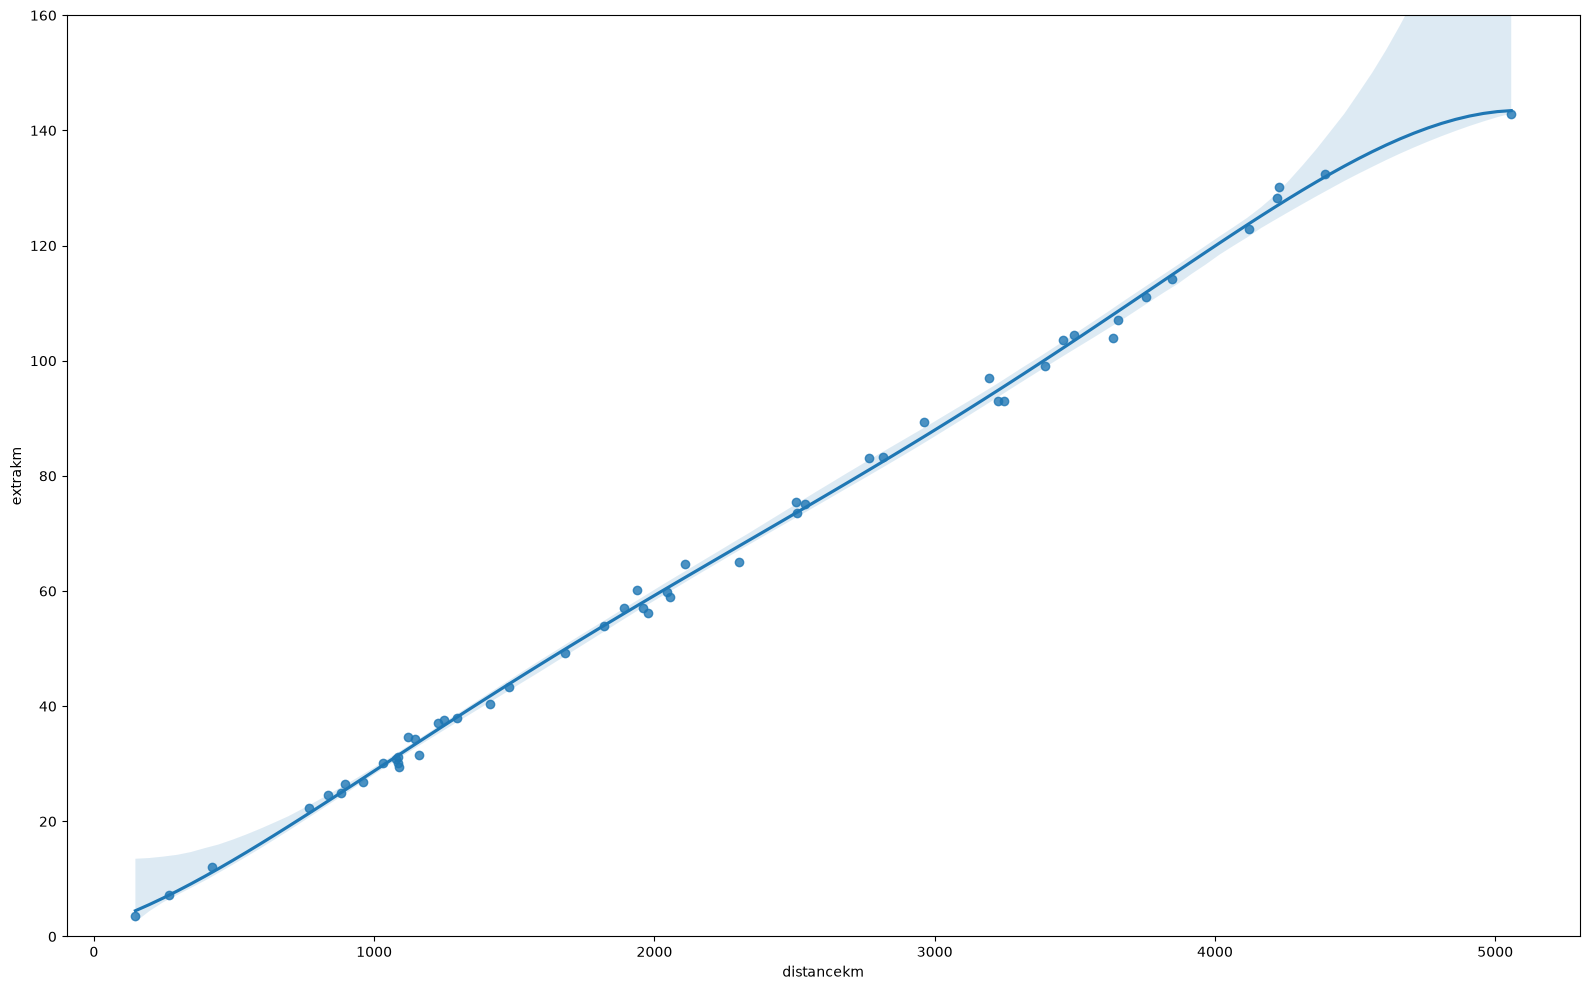

In [ ]:
# seaborn regplot visualisation showing tendency of extra km made by drivers by total trip distance

fig, axis = plt.subplots(figsize=[16,10])

sns.regplot(data=milesgr, x='distancekm', y='extrakm', order=5, ax=axis)

plt.ylim(0, 160)
plt.tight_layout()
plt.show()

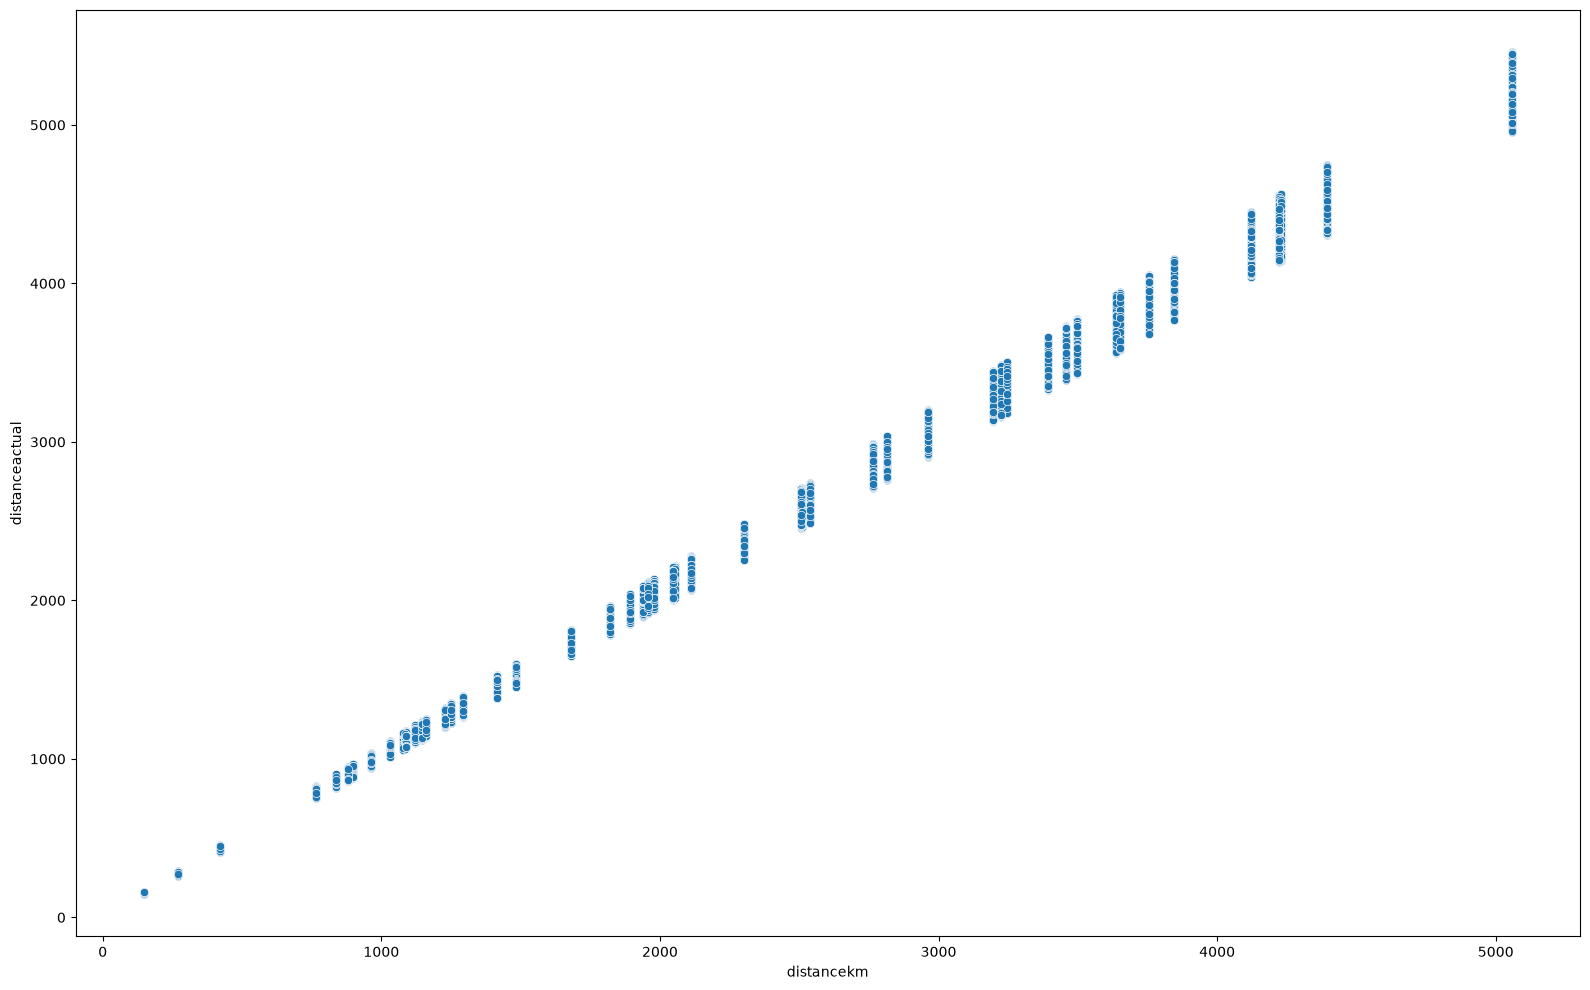

In [ ]:
# seaborn scatterplot visualisation showing a very similar thing
# in a "perfect world" all the dots would make a straight line, but we see the differences due to extra km made by drivers

fig, axis = plt.subplots(figsize=[16,10])

sns.scatterplot(data=miles, x='distancekm', y='distanceactual', ax=axis)

plt.tight_layout()
plt.show()

In [ ]:
# new dataset import with all incidents, routes and exact locations for PowerBI map visualisation purposes

SQL = '''
with a as (select incident_id, trip_id, location_city, location_state from safety_incidents),
b as (select trip_id, load_id from trips),
c as (select load_id, route_id from loads),
d as (select route_id, concat(origin_city, ' -> ', destination_city) as route from routes)
select incident_id, route, location_state, location_city from a
inner join b
on a.trip_id = b.trip_id
inner join c
on b.load_id = c.load_id
inner join d
on c.route_id = d.route_id;
'''
routes = pd.read_sql_query(SQL, con=DB)
routes.head()

,incident_id,route,location_state,location_city
0,INC00000041,Columbus -> Minneapolis,NC,Minneapolis
1,INC00000094,Portland -> Detroit,OH,Columbus
2,INC00000004,Minneapolis -> Houston,TN,Kansas City
3,INC00000159,Seattle -> Houston,OK,Atlanta
4,INC00000135,Atlanta -> Miami,TX,Milwaukee
